# PRACTICA INVESTIGATIVA II

### ESTUDIO DE REPLICACIÓN CONCEPTUAL DEL PAPER TITULADO: 
**To quantum or not to quantum: towards algorithm selection in near-term quantum optimization**

# 1. Introducción

# 2. Antecedentes

Instalación de las librerias

In [2]:
""" %pip install networkx
%pip install qiskit
%pip install qiskit-optimization
%pip install qiskit-algorithms
%pip install cvxpy
%pip install scipy
%pip install scikit-learn
%pip install qiskit_aer """

' %pip install networkx\n%pip install qiskit\n%pip install qiskit-optimization\n%pip install qiskit-algorithms\n%pip install cvxpy\n%pip install scipy\n%pip install scikit-learn\n%pip install qiskit_aer '

Importaciones de las librerias

In [3]:
from networkx import random_regular_graph
import networkx as nx
import networkx.algorithms.approximation as approx

import itertools

from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization.applications import Maxcut
from qiskit_optimization.algorithms import MinimumEigenOptimizer

from qiskit_algorithms.optimizers import NELDER_MEAD

import cvxpy as cp

import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split


In [4]:
#Constantes globales

NMIN = 11
NMAX = 25
Q = 10

Generación del conjunto de grafos regulares de grado 4 aleatorios con 11 a 24 nodos, con 20 instancias por cantidad de nodos para un total de 280 grafos diferentes para las pruebas.

Esto generado mediante la libreria *networkx* y su método *random_regular_graph*

In [5]:
def generate_graphs(nMin,nMax,q):
    gs = []

    for n in range(nMin,nMax):
        for i in range(q):
            gs.append(random_regular_graph(4,n,i*10))
            gs.append(random_regular_graph(4,n,(i+1)*11))
    
    return gs

Algoritmo ingenuo

In [6]:
def brute_force_maxcut(G):
    nodes = list(G.nodes())
    n = len(nodes)
    
    node_to_idx = {node: i for i, node in enumerate(nodes)}
    
    indexed_edges = [(node_to_idx[u], node_to_idx[v]) for u, v in G.edges()]

    best_cut_value = -1
    best_partition = None

    # Recorre todas las posibles particiones binarias
    # Cada nodo puede estar en grupo 0 o grupo 1
    for rest_of_assignment in itertools.product([0, 1], repeat=n-1):
        cut_value = 0
        
        assignment = (0,) + rest_of_assignment
        
        for i, j in indexed_edges:
            if assignment[i] != assignment[j]:
                cut_value += 1

        if cut_value > best_cut_value:
            best_cut_value = cut_value
            best_partition = assignment 

   
    group_0 = [nodes[i] for i, val in enumerate(best_partition) if val == 0]
    group_1 = [nodes[i] for i, val in enumerate(best_partition) if val == 1]

    best_partition = (group_0, group_1)

    return best_cut_value, best_partition

Algoritmo cuantico QAOA

In [86]:
#Convertir MaxCut en un problema QUBO

def graph_to_qubo(G):
    maxcut = Maxcut(G)
    qp = maxcut.to_quadratic_program()
    return qp


#Resolver el problema de MaxCut con QAOA

sampler = StatevectorSampler()
optimizer = NELDER_MEAD(maxiter=250)

def create_solver(depth, initial_point=None):
    qaoa = QAOA(
        sampler=sampler,
        optimizer=optimizer,
        reps=depth,
        initial_point=initial_point
    )

    solver = MinimumEigenOptimizer(qaoa)
    return solver

def solve_qaoa(G,solver):
    qp = graph_to_qubo(G)
    result = solver.solve(qp)
    
    ising_energy = result.min_eigen_solver_result.eigenvalue
    
    num_edges = G.number_of_edges()
    expected_cut_value = (num_edges / 2) - ising_energy

    return int(result.fval), result.x , result.min_eigen_solver_result.optimal_point , float(expected_cut_value)

Algoritmos clasico GW

In [110]:
def goemans_williamson_max_cut(G, num_roundings=100, weight_attr='weight'):
    n = G.number_of_nodes()
    if n == 0:
        return 0, ([], []), 0

    nodes_list = list(G.nodes)
    
    L = nx.laplacian_matrix(G, weight=weight_attr).toarray()
    
    X = cp.Variable((n, n), PSD=True)
    
    objective = cp.Maximize(0.25 * cp.trace(L @ X))
    
    constraints = [cp.diag(X) == 1]
    
    prob = cp.Problem(objective, constraints)
    prob.solve()
    
    sdp_upper_bound = prob.value
    X_val = X.value
    
    evals, evecs = np.linalg.eigh(X_val)
    evals[evals < 0] = 0 
    
    V = evecs @ np.diag(np.sqrt(evals))
    
    best_cut_value = -1
    best_partition = ([], [])
    
    all_cut_values = []
    
    for j in range(num_roundings):
        r = np.random.randn(n)
        
        signs = np.sign(V @ r)
        
        S1 = [nodes_list[i] for i in range(n) if signs[i] >= 0]
        S2 = [nodes_list[i] for i in range(n) if signs[i] < 0]

        current_cut_value = nx.cut_size(G, S1, S2)
        
        all_cut_values.append(float(current_cut_value))

        if current_cut_value > best_cut_value:
            best_cut_value = current_cut_value
            best_partition = (S1, S2)
    
    expected_cut_value = np.mean(all_cut_values)
            
    return best_cut_value, best_partition, sdp_upper_bound, expected_cut_value.tolist()


Generación de pruebas iniciales para la correctitud de los algoritmos

In [111]:
results = []
analisis = []

gs = generate_graphs(6,7,1)
solver = create_solver(2)

for G in gs:
    result_brute_force_maxcut, partition_brute_force_maxcut  =  brute_force_maxcut(G)
    result_QAOA, partition_qaoa, _, _ = solve_qaoa(G,solver)
    result_GW , partition_GW , _ , _ = goemans_williamson_max_cut(G)
    
    results.append([result_brute_force_maxcut,result_QAOA,result_GW])
    analisis.append([partition_brute_force_maxcut,partition_qaoa,partition_GW ])
    
print(results)
print(analisis)

[[8, 8, 8], [8, 8, 8]]
[[([0, 1, 3, 4], [2, 5]), array([0., 1., 1., 0., 1., 1.]), ([1, 2, 4, 5], [0, 3])], [([0, 1, 2, 3], [4, 5]), array([1., 1., 1., 1., 0., 0.]), ([1, 3], [0, 2, 4, 5])]]


#  3. Rendimiento en grafos regulares de grado 4


### Generación de resultados con los métodos clasicos y cuanticos

In [13]:
def generate_values_max_cut_gw(graphs):
    gw_vals = []
    i = 1
    total = len(graphs)
    for G in graphs:
        num_nodes = G.number_of_nodes()
        num_edges = G.number_of_edges()

        print(
            f"\r[GW] Grafo {i}/{total} | Nodos: {num_nodes} | Aristas: {num_edges}",
            end="",
            flush=True
        )
        i += 1
        gw_value,_,_ = goemans_williamson_max_cut(G)
        gw_vals.append(gw_value)
    
    print("\nGW finalizado correctamente.")
        
    return gw_vals

In [79]:
def generate_values_max_cut_qaoa(graphs, qaoaDepth):
    qaoa_vals = []
    previous_params = None

    total = len(graphs)

    for i, G in enumerate(graphs, start=1):
        num_nodes = G.number_of_nodes()
        num_edges = G.number_of_edges()

        try:
            # Crear solver reutilizando los parámetros anteriores
            solver = create_solver(
                depth=qaoaDepth,
                initial_point=previous_params
            )
            
            qaoa_value, _ , previous_params = solve_qaoa(G,solver)
            
            qaoa_vals.append(qaoa_value)

        except Exception as e:
            qaoa_value = -1
            qaoa_vals.append(qaoa_value)

        print(
            f"\r[QAOA] Grafo {i}/{total} | "
            f"Nodos: {num_nodes} | "
            f"Aristas: {num_edges} | "
            f"Depth: {qaoaDepth}",
            end="",
            flush=True
        )

    print("\nQAOA finalizado correctamente.")

    return qaoa_vals


In [ ]:
""" from multiprocessing import Pool, cpu_count

def process_qaoa_graph(args):
    
    G,solver = args
    
    num_nodes = G.number_of_nodes()
    num_edges = G.number_of_edges()
    
    try:
        qaoa_value, _ = solve_qaoa(G, solver)
    except Exception:
        qaoa_value = -1

    return {
        "qaoa_value": qaoa_value,
        "num_nodes": num_nodes,
        "num_edges": num_edges
    }


def generate_values_max_cut_qaoa(graphs, qaoaDepth):
    qaoa_vals = []
    total = len(graphs)
    solver = create_solver(qaoaDepth)
    
    tasks = [(G,solver) for G in graphs]
    
    num_cores = cpu_count()//3
    
    print(f"Iniciando QAOA en paralelo usando {num_cores} núcleos...")
    
    with Pool(num_cores) as pool:
        for i, result in enumerate(pool.imap(process_qaoa_graph, tasks), start=1):
            
            print(
                f"\r[QAOA] Grafo {i}/{total} | "
                f"Nodos: {result['num_nodes']} | "
                f"Aristas: {result['num_edges']} | "
                f"Depth: {qaoaDepth}",
                end="",
                flush=True
            )
            
            qaoa_vals.append(result["qaoa_value"])
    
    print("\nQAOA finalizado correctamente.")
    
    return qaoa_vals """

' from multiprocessing import Pool, cpu_count\n\ndef process_qaoa_graph(args):\n\n    G,solver = args\n\n    num_nodes = G.number_of_nodes()\n    num_edges = G.number_of_edges()\n\n    try:\n        qaoa_value, _ = solve_qaoa(G, solver)\n    except Exception:\n        qaoa_value = -1\n\n    return {\n        "qaoa_value": qaoa_value,\n        "num_nodes": num_nodes,\n        "num_edges": num_edges\n    }\n\n\ndef generate_values_max_cut_qaoa(graphs, qaoaDepth):\n    qaoa_vals = []\n    total = len(graphs)\n    solver = create_solver(qaoaDepth)\n\n    tasks = [(G,solver) for G in graphs]\n\n    num_cores = cpu_count()//3\n\n    print(f"Iniciando QAOA en paralelo usando {num_cores} núcleos...")\n\n    with Pool(num_cores) as pool:\n        for i, result in enumerate(pool.imap(process_qaoa_graph, tasks), start=1):\n\n            print(\n                f"\r[QAOA] Grafo {i}/{total} | "\n                f"Nodos: {result[\'num_nodes\']} | "\n                f"Aristas: {result[\'num_edges\']}

In [19]:
GRAPHS1 =  generate_graphs(11,18,10) #11-17 inclusivo (140 grafos)
GRAPHS2 =  generate_graphs(18,19,10) #18 (20 grafos)
GRAPHS3 =  generate_graphs(19,20,10) #19 (20 grafos)
GRAPHS4 =  generate_graphs(20,21,10) #20 (20 grafos)
GRAPHS = GRAPHS1 + GRAPHS2 + GRAPHS3 + GRAPHS4

In [ ]:
print("INICIO PRIMERA PARTE")

GW_VALS1 = generate_values_max_cut_gw(GRAPHS1) 
QAOA_VALS1 = generate_values_max_cut_qaoa(GRAPHS1,8)

print("EJECUCIÓN FINALIZADA CORRECTAMENTE PRIMERA PARTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("QAOA:\n",QAOA_VALS1)

print("GW:\n",GW_VALS1) 

INICIO PRIMERA PARTE
[GW] Grafo 1/140 | Nodos: 11 | Aristas: 22

[GW] Grafo 140/140 | Nodos: 17 | Aristas: 34
GW finalizado correctamente.
[QAOA] Grafo 140/140 | Nodos: 17 | Aristas: 34 | Depth: 8
QAOA finalizado correctamente.
EJECUCIÓN FINALIZADA CORRECTAMENTE PRIMERA PARTE
---------- VALORES OBTENIDOS ----------
QAOA:
 [18.0, 18.0, 16.0, 18.0, 16.0, 18.0, 18.0, 16.0, 16.0, 16.0, 16.0, 16.0, 18.0, 18.0, 18.0, 16.0, 18.0, 18.0, 16.0, 16.0, 20.0, 18.0, 20.0, 18.0, 20.0, 18.0, 18.0, 18.0, 18.0, 18.0, 20.0, 20.0, 18.0, 20.0, 18.0, 18.0, 20.0, 18.0, 20.0, 20.0, 22.0, 22.0, 20.0, 22.0, 22.0, 18.0, 22.0, 18.0, 20.0, 20.0, 20.0, 20.0, 22.0, 18.0, 22.0, 20.0, 20.0, 20.0, 20.0, 20.0, 20.0, 22.0, 18.0, 24.0, 22.0, 22.0, 20.0, 24.0, 22.0, 20.0, 20.0, 22.0, 22.0, 24.0, 22.0, 20.0, 20.0, 20.0, 24.0, 22.0, 18.0, 24.0, 24.0, 24.0, 26.0, 24.0, 24.0, 24.0, 20.0, 24.0, 24.0, 26.0, 26.0, 24.0, 24.0, 22.0, 20.0, 22.0, 22.0, 24.0, 26.0, 26.0, 24.0, 26.0, 28.0, 26.0, 26.0, 26.0, 24.0, 24.0, 26.0, 24.0, 26.0, 28.0, 20.0, 20.0, 22.0, 26.0, 24.0, 20.0, 28.0, 24.0, 28.0, 22

: 

In [18]:
"Ejecución nodos restantes que dieron error"

print("INICIO PRIMERA PARTE CORRECION DE ERRORES" )

QAOA_VALS1FIX = generate_values_max_cut_qaoa(GRAPHS1[140-14:],3)

print("EJECUCIÓN FINALIZADA CORRECTAMENTE PRIMERA PARTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("QAOA:\n",QAOA_VALS1FIX)

INICIO PRIMERA PARTE CORRECION DE ERRORES
[QAOA] Grafo 14/14 | Nodos: 17 | Aristas: 34 | Depth: 3
QAOA finalizado correctamente.
EJECUCIÓN FINALIZADA CORRECTAMENTE PRIMERA PARTE
---------- VALORES OBTENIDOS ----------
QAOA:
 [28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 28.0, 26.0, 30.0, 28.0, 28.0, 28.0, 28.0, 28.0]


In [13]:
print("INICIO SEGUNDA PARTE")

GW_VALS2 = generate_values_max_cut_gw(GRAPHS2) 
QAOA_VALS2 = generate_values_max_cut_qaoa(GRAPHS2,8)

print("EJECUCIÓN FINALIZADA CORRECTAMENTE SEGUNDA PARTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("QAOA:\n",QAOA_VALS2)

print("GW:\n",GW_VALS2)

INICIO SEGUNDA PARTE
[GW] Grafo 20/20 | Nodos: 18 | Aristas: 36
GW finalizado correctamente.
[QAOA] Grafo 20/20 | Nodos: 18 | Aristas: 36 | Depth: 8
QAOA finalizado correctamente.
EJECUCIÓN FINALIZADA CORRECTAMENTE SEGUNDA PARTE
---------- VALORES OBTENIDOS ----------
QAOA:
 [24.0, 30.0, 32.0, 30.0, 30.0, 30.0, 30.0, 28.0, 30.0, 30.0, 28.0, 30.0, 28.0, 28.0, 30.0, 30.0, 28.0, 30.0, 32.0, 30.0]
GW:
 [28, 30, 32, 30, 30, 30, 30, 28, 30, 30, 28, 30, 28, 28, 30, 30, 28, 30, 32, 30]


In [ ]:
print("INICIO TERCERA PARTE")

GW_VALS3 = generate_values_max_cut_gw(GRAPHS3) 
QAOA_VALS3 = generate_values_max_cut_qaoa(GRAPHS3,8)

print("EJECUCIÓN FINALIZADA CORRECTAMENTE TERCERA PARTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("QAOA:\n",QAOA_VALS3)

print("GW:\n",GW_VALS3)

INICIO SEGUNDA PARTE
[GW] Grafo 20/20 | Nodos: 19 | Aristas: 38
GW finalizado correctamente.
[QAOA] Grafo 20/20 | Nodos: 19 | Aristas: 38 | Depth: 8
QAOA finalizado correctamente.
EJECUCIÓN FINALIZADA CORRECTAMENTE SEGUNDA PARTE
---------- VALORES OBTENIDOS ----------
QAOA:
 [22.0, 28.0, 30.0, 30.0, 34.0, 30.0, 30.0, 30.0, 32.0, 30.0, 30.0, 30.0, 32.0, 32.0, 30.0, 30.0, 30.0, 30.0, 30.0, 32.0]
GW:
 [32, 30, 30, 30, 34, 30, 30, 30, 32, 30, 30, 30, 32, 32, 30, 30, 30, 30, 30, 32]


In [15]:
print("INICIO CUARTA PARTE")

GW_VALS4 = generate_values_max_cut_gw(GRAPHS4) 
QAOA_VALS4 = generate_values_max_cut_qaoa(GRAPHS4,8)

print("EJECUCIÓN FINALIZADA CORRECTAMENTE CUARTA PARTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("QAOA:\n",QAOA_VALS4)

print("GW:\n",GW_VALS4)

INICIO CUARTA PARTE
[GW] Grafo 20/20 | Nodos: 20 | Aristas: 40
GW finalizado correctamente.
[QAOA] Grafo 20/20 | Nodos: 20 | Aristas: 40 | Depth: 8
QAOA finalizado correctamente.
EJECUCIÓN FINALIZADA CORRECTAMENTE CUARTA PARTE
---------- VALORES OBTENIDOS ----------
QAOA:
 [-1, 34, 34, 32, 32, 34, 32, 34, 32, 32, 34, 34, 34, 32, 32, 30, 34, 32, 32, 34]
GW:
 [32, 34, 34, 32, 32, 34, 32, 34, 32, 32, 34, 34, 34, 32, 32, 30, 34, 32, 32, 34]


Recolección de todos los datos

In [30]:
QAOA_VALS = [18, 18, 16, 18, 16, 18, 18, 16, 16, 
16, 16, 16, 18, 18, 18, 16, 18, 18, 16, 16,20, 18, 20, 18, 
20, 18, 18, 18, 18, 18, 20, 20, 18, 20, 18, 18, 20, 18, 20, 
20, 22, 22, 20, 22, 22, 18, 22, 18, 20, 20, 20, 20, 22, 18, 
22, 20, 20, 20, 20, 20, 20, 22, 18, 24, 22, 22, 20, 24, 22,
20, 20, 22, 22, 24, 22, 20, 20, 20, 24, 22, 18, 24, 24, 24, 
26, 24, 24, 24, 20, 24, 24, 26, 26, 24, 24, 22, 20, 22, 22, 
24, 26, 26, 24, 26, 28, 26, 26, 26, 24, 24, 26, 24, 26, 28, 
20, 20, 22, 26, 24, 20, 28, 24, 28, 22, 28, 22,28, 28, 28, 
28, 28, 28, 28, 26, 30, 28, 28, 28, 28, 28, 24, 30, 32, 30, 
30, 30, 30, 28, 30, 30, 28, 30, 28, 28, 30, 30, 28, 30, 32, 
30, 22, 28, 30, 30, 34, 30, 30, 30, 32, 30, 30, 30, 32, 32, 
30, 30, 30, 30, 30, 32,31, 34, 34, 32, 32, 34, 32, 34, 32, 
32, 34, 34, 34, 32, 32, 30, 34, 32, 32, 34]

GW_VALS = [18, 18, 16, 18, 18, 18, 18, 16, 16, 16, 16, 16, 
18, 18, 18, 16, 18, 18, 16, 16, 20, 18, 20, 20, 20, 18, 18,
18, 18, 18, 20, 20, 18, 20, 18, 18, 20, 18, 20, 20, 22, 22, 20,
22, 22, 22, 22, 20, 20, 20, 20, 20, 22, 22, 22, 20, 20, 22, 20,
20, 24, 22, 22, 24, 22, 22, 20, 24, 22, 22, 22, 22, 22, 24, 22,
22, 22, 22, 24, 22, 24, 24, 24, 24, 26, 24, 24, 24, 24, 24, 24, 
26, 26, 24, 24, 24, 24, 22, 22, 24, 26, 26, 24, 26, 28, 26, 26, 
26,24, 26, 26, 26, 26, 28, 26, 26, 26, 26, 26, 26, 28, 28, 28, 
28, 28,26, 28, 28, 28, 28, 28, 28, 28, 26, 30, 28, 28, 28, 28, 
28, 28, 30, 32, 30, 30, 30, 30, 28, 30, 30, 28, 30, 28, 28, 30, 
30, 28, 30, 32, 30, 32, 30, 30, 30, 34, 30, 30, 30, 32, 30, 30, 
30, 32, 32, 30, 30, 30, 30, 30, 32, 32, 34, 34, 32, 32, 34, 32, 
34, 32, 32, 34, 34, 34, 32, 32, 30, 34, 32, 32, 34]

### Generación de resultados con fuerza bruta

In [23]:
def generate_values_max_cut_bf(graphs):
    
    bf_values = []
    i = 0
    total = len(graphs)
    
    for G in graphs:
        num_nodes = G.number_of_nodes()
        num_edges = G.number_of_edges()
        
        best_cut_value, best_partition = brute_force_maxcut(G)
        bf_values.append(best_cut_value)

        print(
            f"\r[GW] Grafo {i}/{total} | Nodos: {num_nodes} | Aristas: {num_edges}",
            end="",
            flush=True
        )
        
        i += 1
        
    return bf_values 

In [28]:
print("INICIO EJECUCIÖN FB")

BF_VALS = generate_values_max_cut_bf(GRAPHS) 

print("EJECUCIÓN FINALIZADA CORRECTAMENTE ")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("BF:\n",BF_VALS)

INICIO EJECUCIÖN FB
[GW] Grafo 199/200 | Nodos: 20 | Aristas: 40EJECUCIÓN FINALIZADA CORRECTAMENTE 
---------- VALORES OBTENIDOS ----------
BF:
 [18, 18, 16, 18, 18, 18, 18, 16, 16, 16, 16, 16, 18, 18, 18, 16, 18, 18, 16, 16, 20, 18, 20, 20, 20, 18, 18, 18, 18, 18, 20, 20, 18, 20, 18, 18, 20, 18, 20, 20, 22, 22, 20, 22, 22, 22, 22, 20, 20, 20, 20, 20, 22, 22, 22, 20, 20, 22, 20, 20, 24, 22, 22, 24, 22, 22, 20, 24, 22, 22, 22, 22, 22, 24, 22, 22, 22, 22, 24, 22, 24, 24, 24, 24, 26, 24, 24, 24, 24, 24, 24, 26, 26, 24, 24, 24, 24, 22, 22, 24, 26, 26, 24, 26, 28, 26, 26, 26, 24, 26, 26, 26, 26, 28, 26, 26, 26, 26, 26, 26, 28, 28, 28, 28, 28, 26, 28, 28, 28, 28, 28, 28, 28, 26, 30, 28, 28, 28, 28, 28, 28, 30, 32, 30, 30, 30, 30, 28, 30, 30, 28, 30, 28, 28, 30, 30, 28, 30, 32, 30, 32, 30, 30, 30, 34, 30, 30, 30, 32, 30, 30, 30, 32, 32, 30, 30, 30, 30, 30, 32, 32, 34, 34, 32, 32, 34, 32, 34, 32, 32, 34, 34, 34, 32, 32, 30, 34, 32, 32, 34]


### Generación de ratio de acertación del algoritmo cuantico y clasico

In [44]:
def generate_ratio_max_cut_gw_qaoa(qaoa_vals,gw_vals,bf_vals):
    
    ratios_gw = []
    ratios_qaoa = []
    
    for i in range(len(bf_vals)):
        bf_act_val = bf_vals[i]
        gw_act_val = gw_vals[i]
        qaoa_act_val = qaoa_vals[i]
        
        ratios_gw.append(gw_act_val/bf_act_val)
        ratios_qaoa.append(qaoa_act_val/bf_act_val)
    
    return ratios_gw, ratios_qaoa


RATIOS_GW,RATIOS_QAOA = generate_ratio_max_cut_gw_qaoa(QAOA_VALS,GW_VALS,BF_VALS)


print("EJECUCIÓN FINALIZADA CORRECTAMENTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("Ratios_qaoa:\n",RATIOS_QAOA,"\n")
print("Ratios_gw:\n",RATIOS_GW)
    

EJECUCIÓN FINALIZADA CORRECTAMENTE
---------- VALORES OBTENIDOS ----------
Ratios_qaoa:
 [1.0, 1.0, 1.0, 1.0, 0.8888888888888888, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8181818181818182, 1.0, 0.9, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8181818181818182, 1.0, 1.0, 1.0, 0.9090909090909091, 1.0, 1.0, 0.8333333333333334, 1.0, 0.8181818181818182, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9090909090909091, 0.9090909090909091, 1.0, 1.0, 1.0, 1.0, 0.9090909090909091, 0.9090909090909091, 0.9090909090909091, 1.0, 1.0, 0.75, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.8333333333333334, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9166666666666666, 0.8333333333333334, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9230769230769231, 1.0, 0.9230769230769231, 1.0, 1.0, 0.7692307692307693, 0.7692307692307693, 0.8461538461538461, 1.0, 0.9230769230769231, 0.769230769230

In [47]:
GRAPHSTEST = generate_graphs(21,25,10)

GWTEST = generate_values_max_cut_gw(GRAPHSTEST)
BFTEST = generate_values_max_cut_bf(GRAPHSTEST)

def generate_ratio_max_cut(gw_vals,bf_vals):
    
    ratios_gw = []
    ratios_qaoa = []
    
    for i in range(len(bf_vals)):
        bf_act_val = bf_vals[i]
        gw_act_val = gw_vals[i]
        
        ratios_gw.append(gw_act_val/bf_act_val)
    
    return ratios_gw


RATIOS_GW_2 = generate_ratio_max_cut(GWTEST,BFTEST)

print("EJECUCIÓN FINALIZADA CORRECTAMENTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("Ratios_gw:\n",RATIOS_GW_2)

[GW] Grafo 80/80 | Nodos: 24 | Aristas: 48
GW finalizado correctamente.
[GW] Grafo 79/80 | Nodos: 24 | Aristas: 48EJECUCIÓN FINALIZADA CORRECTAMENTE
---------- VALORES OBTENIDOS ----------
Ratios_gw:
 [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


### Gaficas de Cajas para comparar los resultados obtenidos

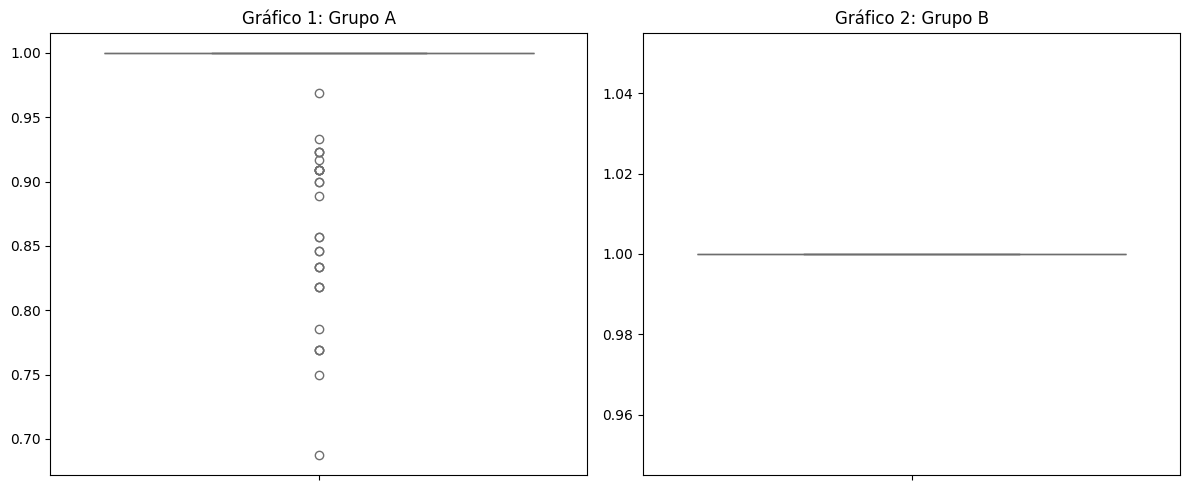

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=RATIOS_QAOA, ax=axes[0], color="skyblue")
axes[0].set_title("Gráfico 1: Grupo A")

sns.boxplot(y=RATIOS_GW, ax=axes[1], color="salmon")
axes[1].set_title("Gráfico 2: Grupo B")

plt.tight_layout()
plt.show()

### Correción de obtención de datos

In [64]:
def generate_values_max_cut_qaoa_avg(graphs, qaoaDepth):
    qaoa_vals = []
    previous_params = None

    total = len(graphs)

    for i, G in enumerate(graphs, start=1):
        num_nodes = G.number_of_nodes()
        num_edges = G.number_of_edges()

        try:
            # Crear solver reutilizando los parámetros anteriores
            solver = create_solver(
                depth=qaoaDepth,
                initial_point=previous_params
            )
            
            _ , _ , previous_params,qaoa_value_avg  = solve_qaoa(G,solver)
            
            qaoa_vals.append(qaoa_value_avg)

        except Exception as e:
            qaoa_value = -1
            qaoa_vals.append(qaoa_value)

        print(
            f"\r[QAOA] Grafo {i}/{total} | "
            f"Nodos: {num_nodes} | "
            f"Aristas: {num_edges} | "
            f"Depth: {qaoaDepth}",
            end="",
            flush=True
        )

    print("\nQAOA finalizado correctamente.")

    return qaoa_vals


def generate_values_max_cut_gw_avg(graphs):
    gw_vals = []
    i = 1
    total = len(graphs)
    for G in graphs:
        num_nodes = G.number_of_nodes()
        num_edges = G.number_of_edges()

        print(
            f"\r[GW] Grafo {i}/{total} | Nodos: {num_nodes} | Aristas: {num_edges}",
            end="",
            flush=True
        )
        i += 1
        _,_,_,expected_cut_value = goemans_williamson_max_cut(G)
        gw_vals.append(expected_cut_value)
    
    print("\nGW finalizado correctamente.")
        
    return gw_vals


In [71]:
print("INICIO CALCULO PROMEDIOS DE VALORES")

GW_VALS_AVG = generate_values_max_cut_gw_avg(GRAPHS1) 
QAOA_VALS_AVG = generate_values_max_cut_qaoa_avg(GRAPHS1,8)

print("EJECUCIÓN FINALIZADA CORRECTAMENTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("QAOA:\n",QAOA_VALS_AVG)

print("GW:\n",GW_VALS_AVG)

INICIO CALCULO PROMEDIOS DE VALORES
[GW] Grafo 140/140 | Nodos: 17 | Aristas: 34
GW finalizado correctamente.
[QAOA] Grafo 140/140 | Nodos: 17 | Aristas: 34 | Depth: 8
QAOA finalizado correctamente.
EJECUCIÓN FINALIZADA CORRECTAMENTE
---------- VALORES OBTENIDOS ----------
QAOA:
 [11.259765625, 11.203125, 10.830078125, 11.10546875, 11.240234375, 11.1875, 11.166015625, 11.23828125, 11.2109375, 11.33203125, 11.419921875, 11.353515625, 11.287109375, 11.296875, 11.787109375, 11.7109375, 11.828125, 11.7734375, 11.712890625, 11.83984375, 12.904296875, 12.58203125, 13.013671875, 12.85546875, 13.02734375, 15.3515625, 16.203125, 16.7890625, 16.5625, 16.71484375, 17.697265625, 17.419921875, 17.146484375, 17.931640625, 17.515625, 16.541015625, 18.17578125, 17.1953125, 17.572265625, 17.884765625, 19.662109375, 19.119140625, 18.94140625, 19.599609375, 19.35546875, 19.12109375, 19.533203125, 18.828125, 18.587890625, 19.072265625, 18.5234375, 18.90234375, 19.671875, 19.2734375, 19.14453125, 18.728515

In [74]:
RATIOS_GW_AVG,RATIOS_QAOA_AVG = generate_ratio_max_cut_gw_qaoa(QAOA_VALS_AVG,GW_VALS_AVG,BF_VALS[:140])


print("EJECUCIÓN FINALIZADA CORRECTAMENTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("Ratios_qaoa:\n",RATIOS_QAOA_AVG,"\n")
print("Ratios_gw:\n",RATIOS_GW_AVG)

EJECUCIÓN FINALIZADA CORRECTAMENTE
---------- VALORES OBTENIDOS ----------
Ratios_qaoa:
 [0.6255425347222222, 0.6223958333333334, 0.6768798828125, 0.6169704861111112, 0.6244574652777778, 0.6215277777777778, 0.6203342013888888, 0.702392578125, 0.70068359375, 0.708251953125, 0.7137451171875, 0.7095947265625, 0.6270616319444444, 0.6276041666666666, 0.6548394097222222, 0.73193359375, 0.6571180555555556, 0.6540798611111112, 0.7320556640625, 0.739990234375, 0.64521484375, 0.6990017361111112, 0.65068359375, 0.6427734375, 0.6513671875, 0.8528645833333334, 0.9001736111111112, 0.9327256944444444, 0.9201388888888888, 0.9286024305555556, 0.88486328125, 0.87099609375, 0.9525824652777778, 0.89658203125, 0.9730902777777778, 0.9189453125, 0.9087890625, 0.9552951388888888, 0.87861328125, 0.89423828125, 0.8937322443181818, 0.8690518465909091, 0.9470703125, 0.8908913352272727, 0.8797940340909091, 0.869140625, 0.8878728693181818, 0.94140625, 0.92939453125, 0.95361328125, 0.926171875, 0.9451171875, 0.89417

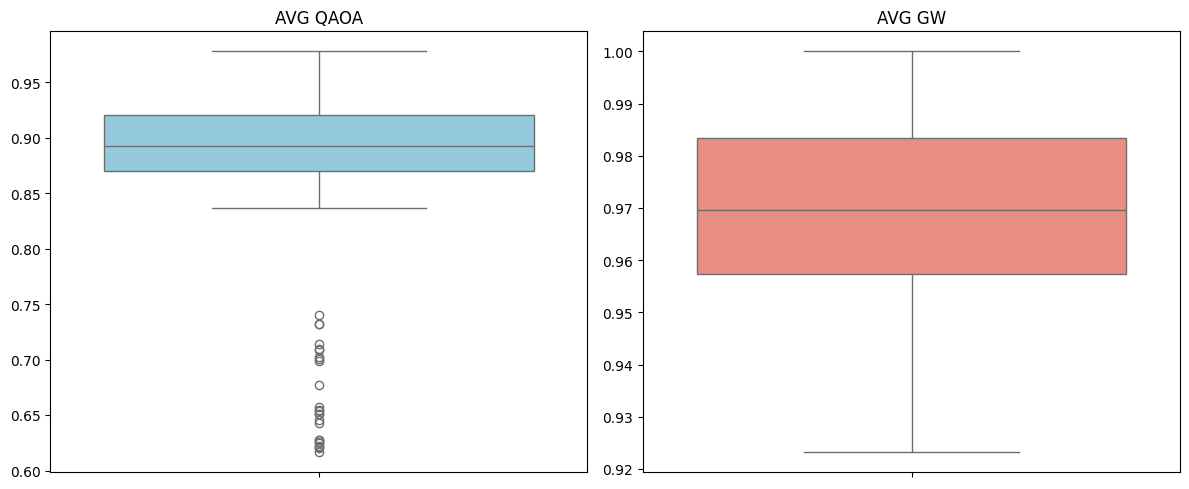

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=RATIOS_QAOA_AVG, ax=axes[0], color="skyblue")
axes[0].set_title("AVG QAOA")

sns.boxplot(y=RATIOS_GW_AVG, ax=axes[1], color="salmon")
axes[1].set_title("AVG GW")

plt.tight_layout()
plt.show()

In [81]:
print("INICIO CALCULO PROMEDIOS DE VALORES CON QAOA P=9 Y MAXIM = 70")

GW_VALS_AVG = generate_values_max_cut_gw_avg(GRAPHS1) 
QAOA_VALS_AVG = generate_values_max_cut_qaoa_avg(GRAPHS1,10)

print("EJECUCIÓN FINALIZADA CORRECTAMENTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("QAOA:\n",QAOA_VALS_AVG)

print("GW:\n",GW_VALS_AVG)

INICIO CALCULO PROMEDIOS DE VALORES CON QAOA P=9 Y MAXIM = 70
[GW] Grafo 140/140 | Nodos: 17 | Aristas: 34
GW finalizado correctamente.
[QAOA] Grafo 140/140 | Nodos: 17 | Aristas: 34 | Depth: 10
QAOA finalizado correctamente.
EJECUCIÓN FINALIZADA CORRECTAMENTE
---------- VALORES OBTENIDOS ----------
QAOA:
 [14.900390625, 15.845703125, 15.41796875, 15.806640625, 16.166015625, 16.724609375, 16.111328125, 15.669921875, 15.52734375, 15.685546875, 15.666015625, 15.736328125, 16.41015625, 16.30078125, 17.177734375, 15.63671875, 16.701171875, 16.90234375, 15.673828125, 15.64453125, 18.33203125, 17.291015625, 18.255859375, 17.88671875, 17.837890625, 17.33984375, 16.873046875, 17.123046875, 16.802734375, 17.03125, 18.169921875, 17.916015625, 17.32421875, 18.30078125, 17.59765625, 16.62109375, 18.361328125, 17.380859375, 17.96484375, 18.275390625, 19.8203125, 19.505859375, 19.041015625, 19.828125, 19.44921875, 19.31640625, 19.79296875, 18.8515625, 18.642578125, 18.96875, 18.462890625, 18.8652343

EJECUCIÓN FINALIZADA CORRECTAMENTE
---------- VALORES OBTENIDOS ----------
Ratios_qaoa:
 [0.8277994791666666, 0.8803168402777778, 0.963623046875, 0.8781467013888888, 0.8981119791666666, 0.9291449652777778, 0.8950737847222222, 0.9793701171875, 0.970458984375, 0.9803466796875, 0.9791259765625, 0.9835205078125, 0.9116753472222222, 0.9055989583333334, 0.9543185763888888, 0.977294921875, 0.9278428819444444, 0.9390190972222222, 0.9796142578125, 0.977783203125, 0.9166015625, 0.9606119791666666, 0.91279296875, 0.8943359375, 0.89189453125, 0.9633246527777778, 0.9373914930555556, 0.9512803819444444, 0.9334852430555556, 0.9461805555555556, 0.90849609375, 0.89580078125, 0.9624565972222222, 0.9150390625, 0.9776475694444444, 0.9233940972222222, 0.91806640625, 0.9656032986111112, 0.8982421875, 0.91376953125, 0.9009232954545454, 0.8866299715909091, 0.95205078125, 0.9012784090909091, 0.8840553977272727, 0.8780184659090909, 0.8996803977272727, 0.942578125, 0.93212890625, 0.9484375, 0.92314453125, 0.9432

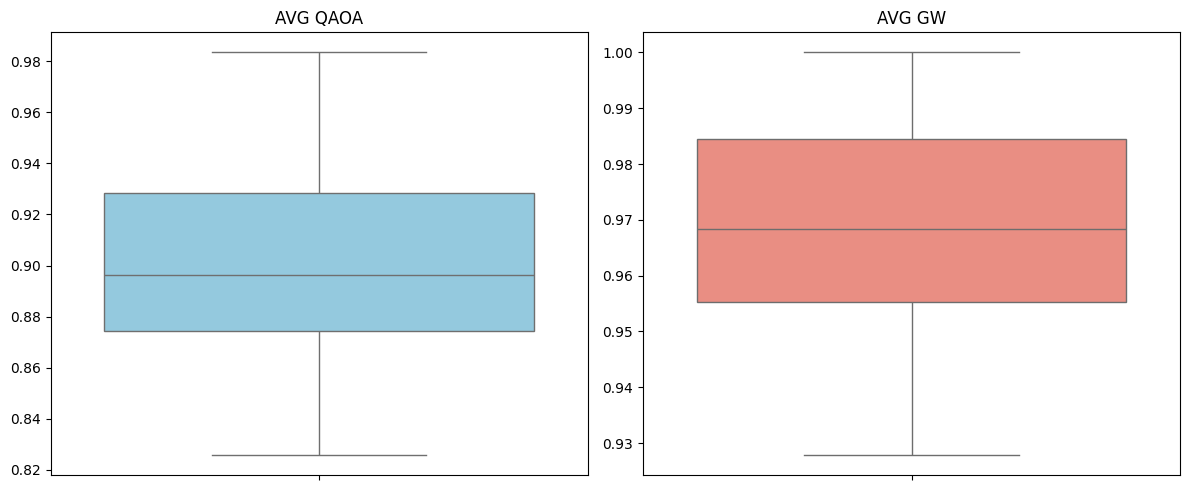

In [83]:
RATIOS_GW_AVG,RATIOS_QAOA_AVG = generate_ratio_max_cut_gw_qaoa(QAOA_VALS_AVG,GW_VALS_AVG,BF_VALS[:140])

print("EJECUCIÓN FINALIZADA CORRECTAMENTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("Ratios_qaoa:\n",RATIOS_QAOA_AVG,"\n")
print("Ratios_gw:\n",RATIOS_GW_AVG)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=RATIOS_QAOA_AVG, ax=axes[0], color="skyblue")
axes[0].set_title("AVG QAOA")

sns.boxplot(y=RATIOS_GW_AVG, ax=axes[1], color="salmon")
axes[1].set_title("AVG GW")

plt.tight_layout()
plt.show()

In [ ]:
print("INICIO CALCULO PROMEDIOS DE VALORES CON QAOA P=10 Y MAXIM = 250")

GW_VALS_AVG = generate_values_max_cut_gw_avg(GRAPHS1) 
QAOA_VALS_AVG = generate_values_max_cut_qaoa_avg(GRAPHS1,10)

print("EJECUCIÓN FINALIZADA CORRECTAMENTE")

print("-"*10, "VALORES OBTENIDOS", "-"*10)

print("QAOA:\n",QAOA_VALS_AVG)

print("GW:\n",GW_VALS_AVG)

# 4. Construcción del Modelo de ML de selección de algoritmo hibridos

## Extracción de los features

Features relacionadas al grafos regulare

In [42]:
#Common features related to regular graphs and the spectrum of the Laplacian matrix

#Return density, log norm laplacian ev(1,2,3,4,5), log laplacian ev ratio, spectral gap

def extract_graph_features(G):
    n = G.number_of_nodes()
    
    if n == 0:
        return None

    density = nx.density(G)
    
    L_norm = nx.normalized_laplacian_matrix(G).toarray()
    
    evals_norm = np.linalg.eigvalsh(L_norm)

    evals_norm = np.maximum(evals_norm, 0)

    evals_norm = np.sort(evals_norm)[::-1]
    

    top_5_norm = np.zeros(5)
    for i in range(min(n, 5)):
        top_5_norm[i] = evals_norm[i]
        
    eps = 1e-10
    log_norm_evs = np.log(top_5_norm + eps)
    

    L_std = nx.laplacian_matrix(G).toarray()
    evals_std = np.linalg.eigvalsh(L_std)
    evals_std = np.maximum(evals_std, 0)
    

    evals_std_desc = np.sort(evals_std)[::-1]
    
    evals_std_asc = np.sort(evals_std)
    
    if n >= 2:
        ratio = (evals_std_desc[0] + eps) / (evals_std_desc[1] + eps)
        log_laplacian_ev_ratio = np.log(ratio)
    else:
        log_laplacian_ev_ratio = 0.0
        
    spectral_gap = evals_std_asc[1] if n >= 2 else 0.0

    features = {
        'density': density,
        'log_norm_laplacian_ev1': log_norm_evs[0],
        'log_norm_laplacian_ev2': log_norm_evs[1],
        'log_norm_laplacian_ev3': log_norm_evs[2],
        'log_norm_laplacian_ev4': log_norm_evs[3],
        'log_norm_laplacian_ev5': log_norm_evs[4],
        'log_laplacian_ev_ratio': log_laplacian_ev_ratio,
        'spectral_gap': spectral_gap
    }
    
    return features

In [41]:
# Set numbers for graphs

#Return independence number over number edges, matching number over number edges, 
# diameter over number edges, domination number over number nodes, 
# zero forcing number over number nodes, power domination over number edges

def extract_set_number_features(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    
    if n == 0 or m == 0:
        return {
            'independence_number_over_number_edges': 0,
            'matching_number_over_number_edges': 0,
            'diameter_over_number_edges': 0,
            'domination_number_over_number_nodes': 0,
            'zero_forcing_number_over_number_nodes': 0,
            'power_domination_over_number_edges': 0
        }

    indep_num = len(approx.maximum_independent_set(G))
    
    matching_num = len(nx.maximal_matching(G))
    
    if nx.is_connected(G):
        diameter = nx.diameter(G)
    else:
        components = (G.subgraph(c) for c in nx.connected_components(G))
        diameter = max(nx.diameter(c) for c in components)
        
    dom_num = len(approx.min_weighted_dominating_set(G))

    def get_zero_forcing_number(G):
        n_nodes = G.number_of_nodes()
        min_zf = n_nodes
        nodes = list(G.nodes())
        for i in range(1, min(n_nodes, 4)):
            import itertools
            for subset in itertools.combinations(nodes, i):
                active = set(subset)
                while True:
                    new_active = False
                    current_active = list(active)
                    for v in current_active:
                        neighbors = set(G.neighbors(v))
                        inactive_neighbors = neighbors - active
                        if len(inactive_neighbors) == 1:
                            active.add(inactive_neighbors.pop())
                            new_active = True
                    if not new_active:
                        break
                if len(active) == n_nodes:
                    return i
        return min_zf

    zf_num = get_zero_forcing_number(G)
    
    # Power Domination approximation
    pd_num = dom_num # Proxy standard as exact is NP-Hard and specific
    
    return {
        'independence_number_over_number_edges': indep_num / m,
        'matching_number_over_number_edges': matching_num / m,
        'diameter_over_number_edges': diameter / m,
        'domination_number_over_number_nodes': dom_num / n,
        'zero_forcing_number_over_number_nodes': zf_num / n,
        'power_domination_over_number_edges': pd_num / n
    }

Features relacionadas al resultado de GW

In [40]:
from scipy.linalg import cholesky

#Features related to the relaxed solution of the semi-definite program in GW and the random projection routine

# Return percent cut,  percent positive lower part relaxation solution, 
# percent close1 lower part relaxation solution, percent close lower part relaxation solution, 
# expected costGW over sdp cost
# std costGW over sdp cost

def extract_gw_relaxation_features(G, num_projections=1000):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    
    if n < 2 or m == 0:
        return {
            'percent_cut': 0.0,
            'percent_positive_lower_part_relaxation_solution': 0.0,
            'percent_close1_lower_part_relaxation_solution': 0.0,
            'percent_close3_lower_part_relaxation_solution': 0.0,
            'expected_costGW_over_sdp_cost': 0.0,
            'std_costGW_over_sdp_cost': 0.0
        }

    nodes_list = list(G.nodes)
    L = nx.laplacian_matrix(G).toarray()
    
    X = cp.Variable((n, n), PSD=True)
    objective = cp.Maximize(0.25 * cp.trace(L @ X))
    constraints = [cp.diag(X) == 1]
    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS) # SCS es rápido para estas dimensiones
    
    sdp_cost = prob.value
    X_val = X.value
    
    # Asegurar que la matriz sea definida positiva para Cholesky por errores numéricos
    X_val = (X_val + X_val.T) / 2
    X_val += np.eye(n) * 1e-9
    
    V = cholesky(X_val, lower=True)
    
    # Extraer elementos de la parte inferior (excluyendo diagonal si se prefiere, 
    # aquí tomamos la matriz triangular inferior completa resultante de Cholesky)
    lower_elements = V[np.tril_indices(n)]
    n_elems = lower_elements.size

    percent_positive = np.sum(lower_elements > 0) / n_elems
    percent_close1 = np.sum(np.abs(lower_elements) < 0.1) / n_elems
    percent_close3 = np.sum(np.abs(lower_elements) < 0.001) / n_elems
    
    costs = []
    for _ in range(num_projections):
        r = np.random.randn(n)
        signs = np.sign(V.T @ r) # V.T porque Cholesky lower da X = V V^T
        S1 = [nodes_list[i] for i in range(n) if signs[i] >= 0]
        S2 = [nodes_list[i] for i in range(n) if signs[i] < 0]
        costs.append(nx.cut_size(G, S1, S2))
        
    costs = np.array(costs)
    
    return {
        'percent_cut': sdp_cost / m,
        'percent_positive_lower_part_relaxation_solution': percent_positive,
        'percent_close1_lower_part_relaxation_solution': percent_close1,
        'percent_close3_lower_part_relaxation_solution': percent_close3,
        'expected_costGW_over_sdp_cost': np.mean(costs) / sdp_cost,
        'std_costGW_over_sdp_cost': np.std(costs) / sdp_cost
    }

Variables Globales de la generación de todas las features para los modelos

In [39]:
class AllFeatures:
    def __init__(self,graphs,qaoa_vals,gw_vals, gw_ratios, qaoa_ratios, bf_vals = None):
        self.featuresI = []
        self.featuresII = []
        self.featuresIII = []
        self.featuresGW_std_and_expected_costGW = []
    
        self.qaoa_vals = qaoa_vals
        self.gw_vals = gw_vals    
        self.bf_vals = bf_vals
        
        self.gw_ratios = gw_ratios
        self.qaoa_ratios = qaoa_ratios
    
    
        for G in graphs:
            gw_relaxation_features = extract_gw_relaxation_features(G)
        
            self.featuresI.append(list(extract_graph_features(G).values()))
            self.featuresII.append(list(extract_set_number_features(G).values()))
            self.featuresIII.append(list(gw_relaxation_features.values())) 
            self.featuresGW_std_and_expected_costGW.append([gw_relaxation_features["expected_costGW_over_sdp_cost"],gw_relaxation_features["std_costGW_over_sdp_cost"]])
    
    

## Metodos para construir el conjunto de datos (data-set)

### Predicting Criterion (1): QAOA vs. GW

Definición de la creación del conjunto de datos tomando todas las features recomendadas en el paper

In [38]:
def build_dataset_creterio_one_all_features(graphs,data):
    X = []
    y = []

    for i in range(len(graphs)):
        featuresI = data.featuresI[i]
        featuresII = data.featuresII[i]
        featuresIII = data.featuresIII[i]
        
        allFeatures = featuresI + featuresII + featuresIII

        qaoa_val = data.qaoa_vals[i]
       
        gw_val = data.gw_vals[i]
        
        label = 1 if gw_val > qaoa_val else 0

        X.append(allFeatures)
        y.append(label)

    return X, y

Definición de la creación del conjunto de datos tomando unicamente las features relacionadas al comportamiento del GW

In [37]:
def build_dataset_creterio_one_gw_features(graphs,data):
    X = []
    y = []

    for i in range(len(graphs)):
        featuresGW = data.featuresGW_std_and_expected_costGW[i]

        qaoa_val = data.qaoa_vals[i]
       
        gw_val = data.gw_vals[i]

        label = 1 if gw_val > qaoa_val else 0

        X.append(featuresGW)
        y.append(label)

    return X, y

### Predicting Criterion (2): QAOA as a High-Performing Heuristic

Definición de la creación del conjunto de datos tomando todas las features recomendadas en el paper

In [36]:
def build_dataset_creterio_two_all_features(graphs,data):
    X = []
    y = []

    for i in range(len(graphs)):
        featuresI = data.featuresI[i]
        featuresII = data.featuresII[i]
        featuresIII = data.featuresIII[i]
        
        allFeatures = featuresI + featuresII + featuresIII
        
        qaoa_val = data.qaoa_vals[i]
        
        max_cut_value = data.bf_vals[i]
        
        ratio_qaoa = data.qaoa_ratios[i]
        ratio_gw = data.gw_ratios[i]
        
        label = 1 if qaoa_val >= max_cut_value * 0.98 and ratio_qaoa >= ratio_gw + 0.02 else 0 

        X.append(allFeatures)
        y.append(label)

    return X, y

Definición de la creación del conjunto de datos tomando solo las features basicas de un grafo

In [35]:
def build_dataset_creterio_two_first_features(graphs,data):
    X = []
    y = []

    for i in range(len(graphs)):
        featuresI = data.featuresI[i]
        
        qaoa_val = data.qaoa_vals[i]
        
        max_cut_value = data.bf_vals[i]
        
        ratio_qaoa = data.qaoa_ratios[i]
        ratio_gw = data.gw_ratios[i]
        
        label = 1 if qaoa_val >= max_cut_value * 0.98 and ratio_qaoa >= ratio_gw + 0.02 else 0 

        X.append(featuresI)
        y.append(label)

    return X, y

## Entrenamiento del Modelo con Sklearn

In [34]:
def train_model(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    model = RandomForestClassifier()
    model.fit(X_train, y_train)

    acc = model.score(X_test, y_test)

    return model, acc

## Pipeline final

In [43]:
# Pipeline general

data = AllFeatures(GRAPHS,QAOA_VALS, GW_VALS, BF_VALS, RATIOS_GW,RATIOS_QAOA)


def pipeline (build_dataset):

    X, y = build_dataset(GRAPHS,data)

    model, acc = train_model(X, y)
    
    return model , acc


# Predicting Criterion (1): QAOA vs. GW

""" model_1_all_features , acc_1_all_features = pipeline(build_dataset_creterio_one_all_features) """

""" model_1_gw_features,  acc_1_gw_features = pipeline(build_dataset_creterio_one_gw_features) """

# Predicting Criterion (2): QAOA as a High-Performing Heuristic

""" model_2_all_features,  acc_2_all_features = pipeline(build_dataset_creterio_two_all_features)

model_2_first_features ,  acc_2_first_features = pipeline(build_dataset_creterio_two_first_features) """

LinAlgError: 5-th leading minor of the array is not positive definite

## Validación cruzada de cada modelo